# Network Properties for Ecoli

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.linear_model import LinearRegression
%matplotlib inline

In [2]:
G = nx.read_adjlist('/content/Ecoli.txt', nodetype=int)

In [3]:
G.number_of_nodes()

1565

In [4]:
G.number_of_edges()

3633

- Diameter

In [5]:
# using builtin funtion
diameter = -1
for component in nx.connected_components(G):
  diameter = max(diameter, nx.diameter(G.subgraph(component)))

diameter

9

In [6]:
# using custom function
diameter = -1
for component in nx.connected_components(G):
  subG = G.subgraph(component)
  for i in component:
    for j in component:
      if i != j:
        path_len = len(nx.shortest_path(subG, i, j)) - 1
        diameter = max(diameter, path_len)

diameter

9

- Degree Distribution

In [7]:
distribution = dict()

total_nodes = G.number_of_nodes()

for node, deg in G.degree():
  distribution.setdefault(deg, 0)
  distribution[deg] += 1

for deg in distribution:
  distribution[deg] /= total_nodes

distribution

{3: 0.1412140575079872,
 7: 0.019808306709265176,
 11: 0.008306709265175719,
 33: 0.0019169329073482429,
 2: 0.2268370607028754,
 18: 0.0006389776357827476,
 4: 0.09520766773162939,
 34: 0.0012779552715654952,
 19: 0.0006389776357827476,
 139: 0.0006389776357827476,
 97: 0.0006389776357827476,
 216: 0.0006389776357827476,
 217: 0.0006389776357827476,
 1: 0.3539936102236422,
 8: 0.008306709265175719,
 430: 0.0006389776357827476,
 10: 0.003194888178913738,
 5: 0.03642172523961661,
 6: 0.06261980830670927,
 157: 0.0006389776357827476,
 221: 0.0006389776357827476,
 115: 0.0006389776357827476,
 25: 0.0012779552715654952,
 49: 0.0006389776357827476,
 277: 0.0006389776357827476,
 30: 0.0006389776357827476,
 9: 0.011501597444089457,
 40: 0.0006389776357827476,
 20: 0.0012779552715654952,
 87: 0.0006389776357827476,
 14: 0.0012779552715654952,
 16: 0.0012779552715654952,
 90: 0.0012779552715654952,
 83: 0.0006389776357827476,
 46: 0.0006389776357827476,
 15: 0.0019169329073482429,
 45: 0.000638

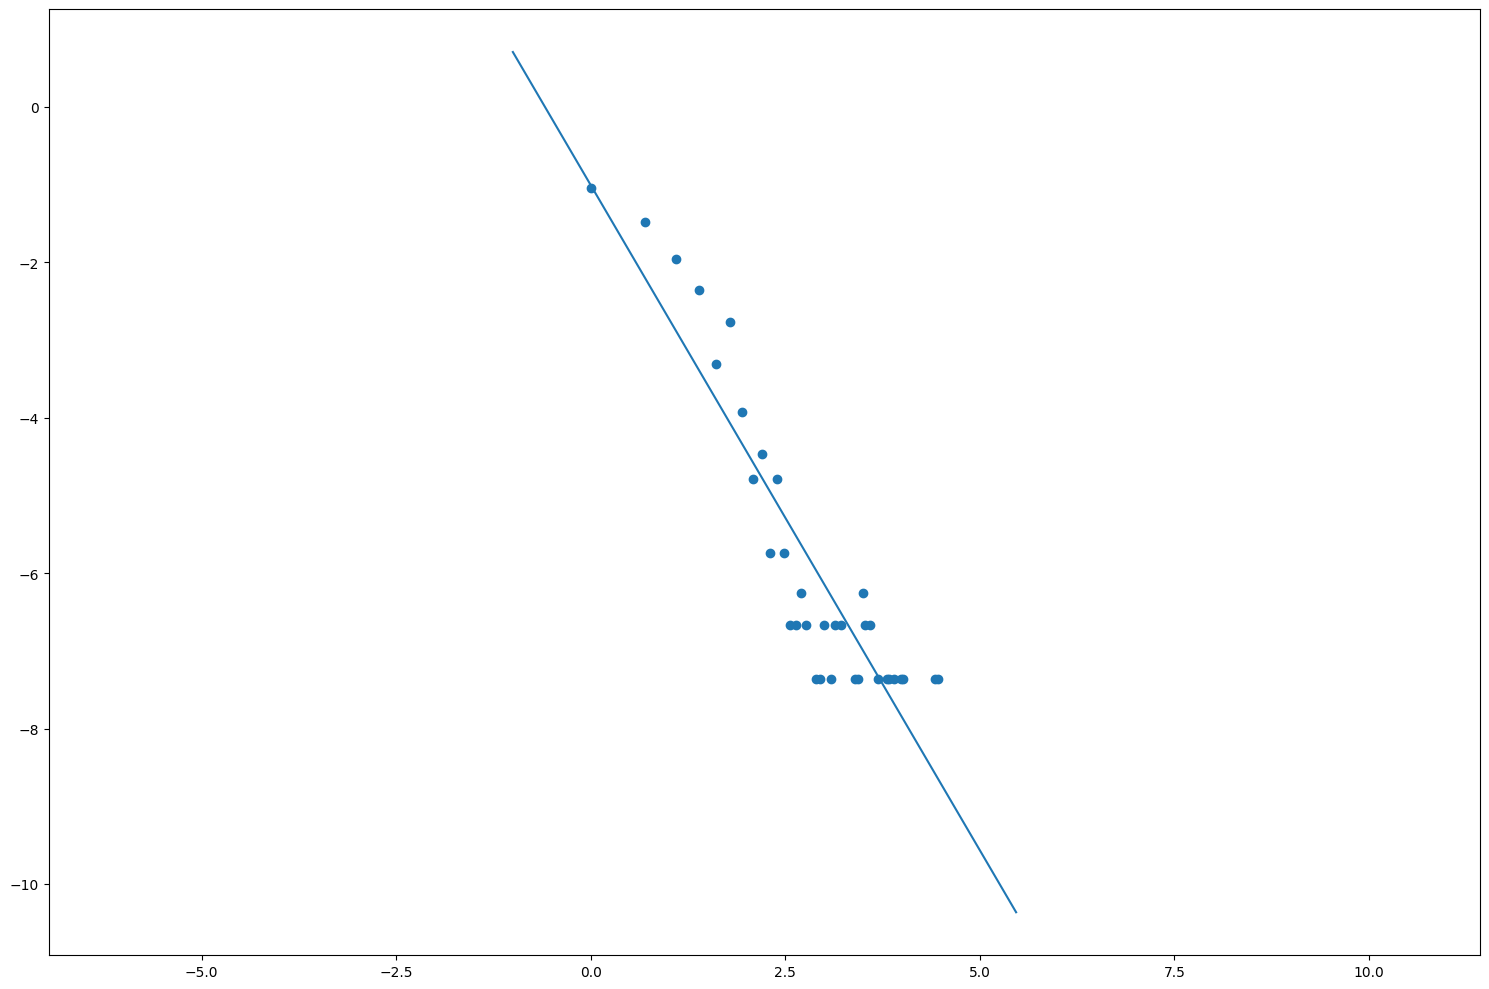

In [8]:
deg, freq = zip(*sorted(list(distribution.items()), key=lambda x: x[0]))

# omit last 10 values
deg = deg[:-10]
freq = freq[:-10]

log_deg = np.log(deg)
log_freq = np.log(freq)

model = LinearRegression()
model.fit(log_deg[:, np.newaxis], log_freq)

x_range = np.linspace(min(log_deg) - 1, max(log_deg) + 1, 1000)
y_range = model.predict(x_range[:, np.newaxis])

fig, ax = plt.subplots(figsize=(15, 10))
ax.plot(x_range, y_range)
ax.scatter(log_deg, log_freq)
ax.axis('equal')
plt.tight_layout()

In [9]:
gamma = -model.intercept_
gamma

1.0051160568647628

- Clustering Coefficient

In [10]:
# custom function
clus_coeff = 0

for node in G.nodes():
  if G.degree(node) > 1:
    num_adj = G.degree[node]

    max_num_edge = num_adj * (num_adj - 1) / 2
    riel_num_edge = len(nx.subgraph(G, nx.neighbors(G, node)).edges)
    coef= riel_num_edge / max_num_edge

    clus_coeff += coef

clus_coeff /= total_nodes
clus_coeff

0.2116414939186282

In [11]:
# using builtin function
coefficient = nx.average_clustering(G)
coefficient

0.2116414939186282

# Page Rank in E. Coli

In [12]:
G = nx.read_adjlist('/content/Ecoli-directed.txt', nodetype=int, create_using=nx.DiGraph)

G.number_of_nodes()

1566

In [13]:
G.number_of_edges()

3759

In [14]:
def ke(i, j):
  if j in G[i]:
    return 1.0

  return 0.0

In [15]:
n = G.number_of_nodes()
d = 0.1

Nr = np.ones((n, n)) / n
N = np.fromfunction(np.vectorize(ke), shape=(n, n))

cond = N.sum(axis=1) > 0
N[cond] /= N[cond].sum(axis=1).reshape((-1, 1))
N[~cond] = 1/n

M = (1-d) * N + d * Nr

pr = np.ones(n)

while True:
  pr_new = M.T @ pr
  pr_new /= pr_new.max() # prevent overflow

  if np.linalg.norm(pr_new - pr) <= 0.001:
    pr = pr_new
    break

  pr = pr_new

pr /= np.linalg.norm(pr)

In [16]:
top_10 = pr.argsort()[-10:]
top_10

array([ 478,  681, 1353, 1354,   19, 1555, 1556, 1155, 1154,  978])